In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ushape.csv')

In [3]:
df.head()

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [5]:
df.columns = ['X','Y','class']

In [6]:
df.head()

,X,Y,class
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [7]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [8]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [23]:
model = Sequential()

model.add(Dense(10,activation='tanh',input_dim=2,kernel_initializer='glorot_uniform'))
model.add(Dense(10,activation='tanh',kernel_initializer='glorot_uniform'))
model.add(Dense(10,activation='tanh',kernel_initializer='glorot_uniform'))
model.add(Dense(10,activation='tanh',kernel_initializer='glorot_uniform'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 10)                30        
                                                                 
 dense_7 (Dense)             (None, 10)                110       
                                                                 
 dense_8 (Dense)             (None, 10)                110       
                                                                 
 dense_9 (Dense)             (None, 10)                110       
                                                                 
 dense_10 (Dense)            (None, 1)                 11        
                                                                 
Total params: 371
Trainable params: 371
Non-trainable params: 0
_________________________________________________________________


In [24]:
model.get_weights()

[array([[-0.6974452 ,  0.01856583,  0.530894  ,  0.06366485, -0.07473308,
         -0.2739174 ,  0.32684427, -0.18989247, -0.59995854, -0.42039037],
        [ 0.179775  ,  0.7026294 ,  0.01445061, -0.68465024,  0.4309438 ,
          0.22990787,  0.4134907 ,  0.6758277 ,  0.18536586, -0.2641245 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.40158385, -0.43668437,  0.28109932, -0.02985209, -0.08842847,
          0.05955219, -0.3574977 ,  0.41474402,  0.27640516,  0.01495761],
        [ 0.18036854, -0.48681134,  0.11311769,  0.5010557 , -0.44406465,
          0.40806437, -0.0774146 , -0.49450788,  0.17884928, -0.39278552],
        [-0.17971545,  0.15738714,  0.4520319 ,  0.3831504 , -0.17084467,
         -0.06484976,  0.53652143,  0.5101973 , -0.30699086,  0.349923  ],
        [-0.4684663 , -0.42302182,  0.23528814, -0.21059778,  0.52130246,
          0.06580293, -0.09529564, -0.24925682, -0.07952985, -0.4337353 ],
        [-0.11835

In [28]:
initial_weights = model.get_weights()

In [29]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [30]:
model.set_weights(initial_weights)

In [31]:
model.get_weights()

[array([[-0.09638014, -0.52053964, -1.1075797 , -0.35144442,  0.83883774,
          0.41136175,  0.24319516,  0.9652818 , -1.0728338 ,  0.15798159],
        [ 0.15589084,  0.7091823 ,  0.01753168, -0.61614513,  0.46020114,
         -0.60342056, -0.3502223 , -0.80223966, -0.3766986 ,  0.23195882]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.09226616,  0.24470593,  0.19279025,  0.19857691,  0.16450526,
         -0.11174601,  0.00129652,  0.06419223, -0.34465915,  0.26869905],
        [ 0.04588016,  0.24625878, -0.3033404 ,  0.588682  , -0.09753534,
          0.07027582,  0.14777435,  0.5806386 ,  0.4158883 , -0.09632844],
        [-0.72867733,  0.07287737,  0.49434236, -0.14632617, -0.04864784,
          0.317529  , -0.28971514,  0.40059566,  0.3487047 , -0.22351998],
        [ 0.25150734,  0.37233   ,  0.1790584 , -0.06524917,  0.07903409,
          0.20118512, -0.1750579 , -0.20880972,  0.07284655, -0.02947644],
        [-0.17019

In [32]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 [==============================] - 1s 72ms/step - loss: 0.6296 - accuracy: 0.7595 - val_loss: 0.6040 - val_accuracy: 0.8500
Epoch 2/100
3/3 [==============================] - 0s 22ms/step - loss: 0.6136 - accuracy: 0.8228 - val_loss: 0.5818 - val_accuracy: 0.8500
Epoch 3/100
3/3 [==============================] - 0s 23ms/step - loss: 0.5995 - accuracy: 0.7975 - val_loss: 0.5606 - val_accuracy: 0.8500
Epoch 4/100
3/3 [==============================] - 0s 22ms/step - loss: 0.5862 - accuracy: 0.7975 - val_loss: 0.5405 - val_accuracy: 0.8500
Epoch 5/100
3/3 [==============================] - 0s 21ms/step - loss: 0.5746 - accuracy: 0.7848 - val_loss: 0.5224 - val_accuracy: 0.8500
Epoch 6/100
3/3 [==============================] - 0s 22ms/step - loss: 0.5626 - accuracy: 0.7848 - val_loss: 0.5063 - val_accuracy: 0.8500
Epoch 7/100
3/3 [==============================] - 0s 22ms/step - loss: 0.5521 - accuracy: 0.7848 - val_loss: 0.4913 - val_accuracy: 0.8500
Epoch 8/100
3/3 [===

In [33]:
model.get_weights()

[array([[-0.21705388, -0.4656159 , -0.92625487, -0.29486814,  0.9771928 ,
          0.383852  ,  0.18989563,  0.7427599 , -0.88805795,  0.15977345],
        [ 0.22989729,  0.7353235 ,  0.09314978, -0.6915629 ,  0.50174034,
         -0.69433004, -0.31660593, -0.93992007, -0.29588428,  0.331146  ]],
       dtype=float32),
 array([-0.08130596,  0.12625672, -0.04455194,  0.04620741, -0.17308837,
        -0.04188232, -0.03539735, -0.07312427, -0.02426066,  0.00602675],
       dtype=float32),
 array([[ 0.07154328,  0.15625598,  0.2678881 ,  0.11085662,  0.2615482 ,
         -0.20988385, -0.09199087,  0.17367174, -0.48754543,  0.13165501],
        [ 0.08385335,  0.1686196 , -0.22949618,  0.54749763, -0.03067322,
         -0.00629453,  0.05763717,  0.6778412 ,  0.34578165, -0.21590015],
        [-0.7859578 ,  0.05136929,  0.4341109 , -0.11672994,  0.01428648,
          0.2997324 , -0.19885348,  0.38167325,  0.29046902, -0.11584122],
        [ 0.20439422,  0.43999147,  0.09808215, -0.01555112, 

9600/9600 [==============================] - 14s 1ms/step


<Axes: >

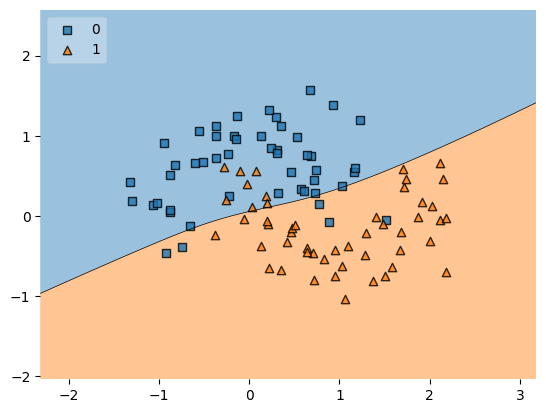

In [34]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

In [35]:
(np.random.randn(10,10)*0.01).min()

-0.02874220504983479

In [36]:
(np.random.randn(10,10)*0.01).max()

0.0185265112777588